In [5]:
from pathlib import Path
import sys
import json
import time

import numpy as np
import nibabel as nib

from scipy.ndimage import zoom

PROJECT_ROOT = Path.cwd().parent

sys.path.append(
    str(PROJECT_ROOT / "src")
)

print("Project root:", PROJECT_ROOT)

Project root: /Users/abhra/Downloads/AI-ML/Resume/BraTS


# 2. V3 Configuration

In [6]:
DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

V3_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "v3"
)

METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "v3"
)

TARGET_SIZE = 128

MODALITIES = [
    "t1",
    "t1ce",
    "t2",
    "flair"
]

print("Dataset:", DATASET_DIR)
print("Output:", V3_OUTPUT_DIR)
print("Metadata:", METADATA_DIR)
print("Target size:", TARGET_SIZE)
print("Modalities:", MODALITIES)

Dataset: /Users/abhra/Downloads/AI-ML/Resume/BraTS/data/raw
Output: /Users/abhra/Downloads/AI-ML/Resume/BraTS/data/processed/v3
Metadata: /Users/abhra/Downloads/AI-ML/Resume/BraTS/data/metadata/v3
Target size: 128
Modalities: ['t1', 't1ce', 't2', 'flair']


# 3. Load V2-compatible metadata

In [12]:
with open(
    METADATA_DIR / "patient_split.json",
    "r"
) as f:
    patient_split = json.load(f)

with open(
    METADATA_DIR / "sampled_slices.json",
    "r"
) as f:
    sampled_slices = json.load(f)


train_ids = patient_split["train_ids"]
val_ids = patient_split["val_ids"]


print("Train patients:", len(train_ids))
print("Validation patients:", len(val_ids))
print("Sampled patients:", len(sampled_slices))

Train patients: 999
Validation patients: 252
Sampled patients: 4


In [15]:
# ==================================================
# Extract V2 Sample Lists
# ==================================================

train_samples = sampled_slices["train"]
val_samples = sampled_slices["val"]

print("Training samples:", len(train_samples))
print("Validation samples:", len(val_samples))

print("\nFirst training sample:")
print(train_samples[0])

print("\nFirst validation sample:")
print(val_samples[0])

Training samples: 16000
Validation samples: 4000

First training sample:
['BraTS-GLI-01047-000', 15]

First validation sample:
['BraTS-GLI-00030-000', 59]


In [17]:
# ==================================================
# Select one patient
# ==================================================


patient_id = "BraTS-GLI-01250-000"

patient_train_slices = [
    slice_idx
    for pid, slice_idx in train_samples
    if pid == patient_id
]

patient_val_slices = [
    slice_idx
    for pid, slice_idx in val_samples
    if pid == patient_id
]

print("Patient:", patient_id)

print(
    "Training slices:",
    patient_train_slices
)

print(
    "Validation slices:",
    patient_val_slices
)

Patient: BraTS-GLI-01250-000
Training slices: [143, 25, 96, 85, 108, 57, 15, 111, 27, 107, 52, 104, 133, 128, 131, 59]
Validation slices: []


In [18]:
# ==================================================
# Verify V2 Sample Selection
# ==================================================

print("Patient:", patient_id)
print("V2 selected slices:", patient_train_slices)
print("Number of slices:", len(patient_train_slices))

print()

# Check whether patient belongs to training split
print(
    "Patient in train split:",
    patient_id in train_ids
)

print(
    "Patient in validation split:",
    patient_id in val_ids
)

Patient: BraTS-GLI-01250-000
V2 selected slices: [143, 25, 96, 85, 108, 57, 15, 111, 27, 107, 52, 104, 133, 128, 131, 59]
Number of slices: 16

Patient in train split: True
Patient in validation split: False


In [23]:
# ==================================================
# Load MRI Volumes
# ==================================================

patient_dir = DATASET_DIR / patient_id

modality_files = {
    "t1": f"{patient_id}-t1n.nii.gz",
    "t1ce": f"{patient_id}-t1c.nii.gz",
    "t2": f"{patient_id}-t2w.nii.gz",
    "flair": f"{patient_id}-t2f.nii.gz",
}

volumes = {}

for modality, filename in modality_files.items():

    path = patient_dir / filename

    volume = nib.load(
        path
    ).get_fdata(
        dtype=np.float32
    )

    volumes[modality] = volume

    print(
        "  Shape:",
        volume.shape
    )

  Shape: (240, 240, 155)
  Shape: (240, 240, 155)
  Shape: (240, 240, 155)
  Shape: (240, 240, 155)


In [24]:
# ==================================================
# Normalize MRI Volumes
# ==================================================

for modality in MODALITIES:

    volume = volumes[modality]

    # Brain/non-zero voxels
    mask = volume > 0

    mean = volume[mask].mean()
    std = volume[mask].std()

    if std > 0:
        volume[mask] = (
            (volume[mask] - mean) / std
        )

    volumes[modality] = volume

    print(
        f"{modality}: "
        f"mean={volume[mask].mean():.4f}, "
        f"std={volume[mask].std():.4f}"
    )

t1: mean=0.0000, std=1.0000
t1ce: mean=-0.0000, std=1.0000
t2: mean=-0.0000, std=1.0000
flair: mean=0.0000, std=1.0000


In [25]:
# ==================================================
# Load Segmentation Mask
# ==================================================

seg_path = (
    patient_dir
    / f"{patient_id}-seg.nii.gz"
)

seg = nib.load(
    seg_path
).get_fdata()

# Convert all tumor labels to binary
seg = (
    seg > 0
).astype(np.float32)

print("Segmentation shape:", seg.shape)
print("Mask dtype:", seg.dtype)
print("Mask values:", np.unique(seg))

Segmentation shape: (240, 240, 155)
Mask dtype: float32
Mask values: [0. 1.]


In [26]:
# ==================================================
# Build One 2.5D Sample
# ==================================================

z = patient_train_slices[0]

prev_z = max(z - 1, 0)
next_z = min(
    z + 1,
    seg.shape[-1] - 1
)

print("Target slice:", z)
print("Previous slice:", prev_z)
print("Next slice:", next_z)


# --------------------------------------------------
# Stack modalities
# --------------------------------------------------

mri = np.stack(
    [
        volumes["t1"],
        volumes["t1ce"],
        volumes["t2"],
        volumes["flair"]
    ],
    axis=0
)

print(
    "\nMRI volume shape:",
    mri.shape
)


# --------------------------------------------------
# Extract adjacent slices
# --------------------------------------------------

previous = mri[:, :, :, prev_z]

current = mri[:, :, :, z]

next_slice = mri[:, :, :, next_z]


print("Previous:", previous.shape)
print("Current:", current.shape)
print("Next:", next_slice.shape)


# --------------------------------------------------
# Concatenate → 12 channels
# --------------------------------------------------

image_2_5d = np.concatenate(
    [
        previous,
        current,
        next_slice
    ],
    axis=0
)

mask_2d = seg[:, :, z]


print(
    "\n2.5D image shape:",
    image_2_5d.shape
)

print(
    "Target mask shape:",
    mask_2d.shape
)

print(
    "Image dtype:",
    image_2_5d.dtype
)

print(
    "Mask dtype:",
    mask_2d.dtype
)

Target slice: 143
Previous slice: 142
Next slice: 144

MRI volume shape: (4, 240, 240, 155)
Previous: (4, 240, 240)
Current: (4, 240, 240)
Next: (4, 240, 240)

2.5D image shape: (12, 240, 240)
Target mask shape: (240, 240)
Image dtype: float32
Mask dtype: float32


In [27]:
# ==================================================
# Resize V3 Sample to 128 × 128
# ==================================================

scale = 128 / image_2_5d.shape[-1]

print("Scale factor:", scale)

# --------------------------------------------------
# Resize MRI
# --------------------------------------------------

image_resized = zoom(
    image_2_5d,
    (
        1,
        scale,
        scale
    ),
    order=1
)

# --------------------------------------------------
# Resize mask
# --------------------------------------------------

mask_resized = zoom(
    mask_2d,
    scale,
    order=0
)

# --------------------------------------------------
# Verify
# --------------------------------------------------

print(
    "Resized image shape:",
    image_resized.shape
)

print(
    "Resized mask shape:",
    mask_resized.shape
)

print(
    "Image dtype:",
    image_resized.dtype
)

print(
    "Mask dtype:",
    mask_resized.dtype
)

print(
    "Mask values:",
    np.unique(mask_resized)
)

Scale factor: 0.5333333333333333
Resized image shape: (12, 128, 128)
Resized mask shape: (128, 128)
Image dtype: float32
Mask dtype: float32
Mask values: [0.]


In [28]:
# ==================================================
# Verify Target Slice
# ==================================================

print("Target slice:", z)

print(
    "Original mask pixels:",
    int(mask_2d.sum())
)

print(
    "Resized mask pixels:",
    int(mask_resized.sum())
)

print(
    "Original mask unique values:",
    np.unique(mask_2d)
)

print(
    "Resized mask unique values:",
    np.unique(mask_resized)
)

Target slice: 143
Original mask pixels: 0
Resized mask pixels: 0
Original mask unique values: [0.]
Resized mask unique values: [0.]


In [29]:
# ==================================================
# Check All Selected Slices
# ==================================================

print("Patient:", patient_id)
print()

for slice_idx in patient_train_slices:

    tumor_pixels = int(
        seg[:, :, slice_idx].sum()
    )

    print(
        f"Slice {slice_idx:3d} → "
        f"{tumor_pixels:5d} tumor pixels"
    )

Patient: BraTS-GLI-01250-000

Slice 143 →     0 tumor pixels
Slice  25 →     0 tumor pixels
Slice  96 →  1445 tumor pixels
Slice  85 →  1815 tumor pixels
Slice 108 →   200 tumor pixels
Slice  57 →    74 tumor pixels
Slice  15 →     0 tumor pixels
Slice 111 →     0 tumor pixels
Slice  27 →     0 tumor pixels
Slice 107 →   281 tumor pixels
Slice  52 →    21 tumor pixels
Slice 104 →   578 tumor pixels
Slice 133 →     0 tumor pixels
Slice 128 →     0 tumor pixels
Slice 131 →     0 tumor pixels
Slice  59 →   233 tumor pixels


In [30]:
# ==================================================
# Tumor-Containing V3 Sanity Check
# ==================================================

z = 96

prev_z = max(z - 1, 0)
next_z = min(
    z + 1,
    seg.shape[-1] - 1
)

print("Previous:", prev_z)
print("Target:", z)
print("Next:", next_z)

# --------------------------------------------------
# Extract 3-slice context
# --------------------------------------------------

previous = mri[:, :, :, prev_z]
current = mri[:, :, :, z]
next_slice = mri[:, :, :, next_z]

image_2_5d = np.concatenate(
    [
        previous,
        current,
        next_slice
    ],
    axis=0
)

mask_2d = seg[:, :, z]

# --------------------------------------------------
# Resize
# --------------------------------------------------

scale = 128 / image_2_5d.shape[-1]

image_resized = zoom(
    image_2_5d,
    (1, scale, scale),
    order=1
)

mask_resized = zoom(
    mask_2d,
    scale,
    order=0
)

print()
print(
    "V3 image:",
    image_resized.shape
)

print(
    "V3 mask:",
    mask_resized.shape
)

print(
    "Original tumor pixels:",
    int(mask_2d.sum())
)

print(
    "Resized tumor pixels:",
    int(mask_resized.sum())
)

print(
    "Mask values:",
    np.unique(mask_resized)
)

Previous: 95
Target: 96
Next: 97

V3 image: (12, 128, 128)
V3 mask: (128, 128)
Original tumor pixels: 1445
Resized tumor pixels: 407
Mask values: [0. 1.]


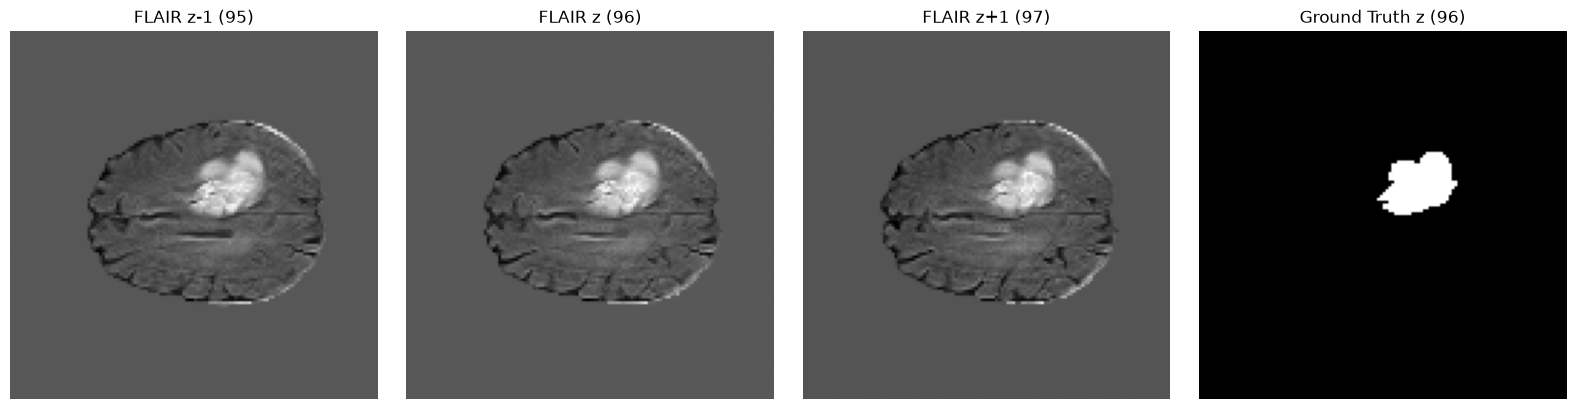

In [33]:
# ==================================================
# Visualize 2.5D Context
# ==================================================
import matplotlib.pyplot as plt
# FLAIR is channel 3 within each 4-channel group
flair_previous = image_resized[3]
flair_current = image_resized[7]
flair_next = image_resized[11]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

axes[0].imshow(
    flair_previous,
    cmap="gray"
)

axes[0].set_title(
    f"FLAIR z-1 ({prev_z})"
)

axes[1].imshow(
    flair_current,
    cmap="gray"
)

axes[1].set_title(
    f"FLAIR z ({z})"
)

axes[2].imshow(
    flair_next,
    cmap="gray"
)

axes[2].set_title(
    f"FLAIR z+1 ({next_z})"
)

axes[3].imshow(
    mask_resized,
    cmap="gray"
)

axes[3].set_title(
    f"Ground Truth z ({z})"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [34]:
PROJECT_ROOT = Path.cwd().parent

TRAIN_V3_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "v3"
    / "train"
)

VAL_V3_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "v3"
    / "val"
)

train_files = sorted(
    TRAIN_V3_DIR.glob("*.npz")
)

val_files = sorted(
    VAL_V3_DIR.glob("*.npz")
)

print("Train patients:", len(train_files))
print("Validation patients:", len(val_files))

Train patients: 999
Validation patients: 252


In [35]:
sample_file = train_files[0]

data = np.load(sample_file)

images = data["images"]
masks = data["masks"]

print("File:", sample_file.name)

print()
print("Images:")
print("  Shape:", images.shape)
print("  Dtype:", images.dtype)

print()
print("Masks:")
print("  Shape:", masks.shape)
print("  Dtype:", masks.dtype)

print()
print("Mask values:", np.unique(masks))
print("Positive slices:", np.sum(masks.sum(axis=(1, 2)) > 0))

File: BraTS-GLI-00002-000.npz

Images:
  Shape: (16, 12, 128, 128)
  Dtype: float32

Masks:
  Shape: (16, 128, 128)
  Dtype: float32

Mask values: [0. 1.]
Positive slices: 8
